# Performance Comparison: SA vs PA vs GA

This notebook reproduces the performance comparison figure from [arXiv:2510.19544](https://arxiv.org/abs/2510.19544), benchmarking three annealing algorithms on a 3D Ising spin glass ($L=10$, $N=1000$):

- **SA** (Simulated Annealing): standard local Metropolis updates through a temperature schedule.
- **PA** (Population Annealing): adds Boltzmann resampling at each temperature step, biasing the population toward low-energy configurations.
- **GA** (Global Annealing): augments PA-style annealing with MADE-based global moves that propose full-configuration updates via a learned autoregressive model.

We compare $\Delta E$ (the running minimum energy per spin) as a function of wall-clock time for three different time budgets.

In [65]:
import torch
import numpy as np
import sys
import time
from copy import deepcopy
import matplotlib.pyplot as plt
from IPython.display import Image

sys.path.append("./Code/Legacy/packages")
sys.path.append("./Code/Modern/optimization")

from device_utils import get_best_device
from geometry import *
from utilities import *
from data_loads import *
from monte_carlo import *
from made import *
from global_steps import *
from simulated_annealing import *
from population_annealing import *
from global_annealing import *
from greedy import *

In [6]:
if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
  print('Apple Metal GPU available through PyTorch MPS')
elif torch.cuda.is_available():
  print('Number of available GPUs: ', torch.cuda.device_count())
  for i in range(0, torch.cuda.device_count()):
    print(torch.cuda.get_device_name(i))

device = get_best_device()
print(f"Computation device: {device}\n")

Number of available GPUs:  3
Tesla V100S-PCIE-32GB
Tesla V100S-PCIE-32GB
Tesla V100S-PCIE-32GB
Computation device: cuda



## Fixed Parameters

All algorithms share the same coupling instance, temperature range, and number of local MC sweeps per step.

In [17]:
# Temperature range
Tstart = 1.92
Tend = 0.1

# Local Metropolis sweeps per temperature step
local_moves = 15

# GA-specific: global MADE moves and training hyper-parameters
global_moves = 5
num_epochs_start = 40
num_epochs_retrain = 1
batch_size = 256

# Temperature schedule type (logarithmic in T)
schedule = "logT"

# System size: 3D Ising spin glass on an L×L×L cubic lattice
L = 10
N = L * L * L

# Greedy Algorithm

Greedy Search performs local Metropolis sweeps at zero temperature. Only moves that decrease or maintain energy are accepted; no temperature schedule or global moves.

[GREEDY] All replicas reached a local minimum at step 397 / 15000.
15 -1.53106 -1.43082 16.275


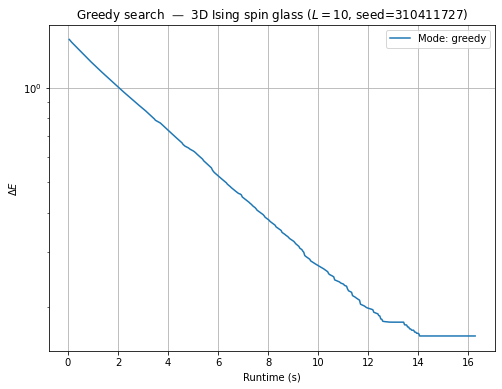

In [13]:
# Population size (number of replicas)
pop_size = 100_000

# algorithm mode
mode = "greedy" # "greedy", "random" or "reluctant"

# Disorder instance
instance = 310411727  # hard instance
E_gs = -1.69300   # ground state energy for the hard instance
#instance = 10069     # easy instance (uncomment to switch)
#E_gs = -1.74178   # ground state energy for the easy instance

# Load coupling matrix
J = read_couplings(f'./Data/Alpha/Couplings/couplings_L{L}_R1_seed{instance}.txt', N).to(device)


observ, elapsed_time =  greedy_search(
    L, J, pop_size, local_moves, Observables, mode
    )


time_list = np.array(observ.get_elapsed_times())
min_energy_list = np.array(observ.get_running_min_energy())
print(local_moves, f"{np.min(min_energy_list):.5f}", f'{observ.get_observable_history("mean_energy")[-1]:.5f}', f"{elapsed_time:.3f}")


plt.figure(figsize=(8, 6))
plt.title(f"Greedy search  —  3D Ising spin glass ($L={L}$, instance={instance})")
plt.plot(time_list, min_energy_list - E_gs, label=f"Mode: {mode}", color="tab:blue")
plt.xlabel("Runtime (s)")
plt.ylabel(r"$\Delta E$")
plt.yscale("log")
plt.grid()
plt.legend()
plt.show()

Comparing Greedy Algorithms (L=10, N=1000, pop_size=100,000)
Ground State Energy E_gs = -1.69300

Running GREEDY greedy search...
[GREEDY] All replicas reached a local minimum at step 407 / 15000.
Running RANDOM greedy search...
[RANDOM] All replicas reached a local minimum at step 573 / 15000.
Running RELUCTANT greedy search...
[RELUCTANT] All replicas reached a local minimum at step 1073 / 15000.

Mode         | Min Energy   | Gap to E_gs  | Final Mean E   | Time (s)
----------------------------------------------------------------------
Greedy       | -1.54448     | 0.14852      | -1.43050       | 17.68   
Random       | -1.51394     | 0.17906      | -1.39592       | 22.95   
Reluctant    | -1.48298     | 0.21002      | -1.36839       | 46.12   


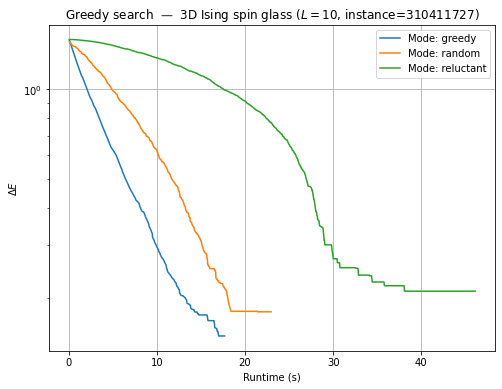

In [18]:
pop_size = 100_000

# Disorder instance
instance = 310411727  # hard instance
E_gs = -1.69300   # ground state energy for the hard instance
# instance = 10069     # easy instance (uncomment to switch)
# E_gs = -1.74178   # ground state energy for the easy instance

# Load coupling matrix
J = read_couplings(f'./Data/Alpha/Couplings/couplings_L{L}_R1_seed{instance}.txt', N).to(device)

# Modes to compare
modes = ["greedy", "random", "reluctant"]
results = {}

print(f"{'='*65}")
print(f"Comparing Greedy Algorithms (L={L}, N={N}, pop_size={pop_size:,})")
print(f"Ground State Energy E_gs = {E_gs:.5f}")
print(f"{'='*65}\n")

for mode in modes:
    print(f"Running {mode.upper()} greedy search...")

    observ, elapsed_time = greedy_search(
        L=L, 
        J=J, 
        pop_size=pop_size, 
        num_sweeps=local_moves, 
        Observables=Observables, 
        mode=mode, 
    )

    # Extract metrics
    min_energy_hist = observ.get_observable_history("min_energy")
    mean_energy_hist = observ.get_observable_history("mean_energy")
    
    min_energy = float(torch.tensor(min_energy_hist).min())
    final_mean_energy = float(mean_energy_hist[-1])
    energy_gap = abs(min_energy - E_gs)

    results[mode] = {
        "min_energy": min_energy,
        "mean_energy": final_mean_energy,
        "gap_to_gs": energy_gap,
        "time": elapsed_time,
        "observ": observ,
        "time_list": np.array(observ.get_elapsed_times()),
        "min_energy_list": np.array(observ.get_running_min_energy())
    }

# ----------------- Summary Comparison Table ----------------- #
print("\n" + "="*70)
print(f"{'Mode':<12} | {'Min Energy':<12} | {'Gap to E_gs':<12} | {'Final Mean E':<14} | {'Time (s)':<8}")
print("-" * 70)
for mode, res in results.items():
    print(f"{mode.capitalize():<12} | "
          f"{res['min_energy']:<12.5f} | "
          f"{res['gap_to_gs']:<12.5f} | "
          f"{res['mean_energy']:<14.5f} | "
          f"{res['time']:<8.2f}")
print("="*70)



plt.figure(figsize=(8, 6))
plt.title(f"Greedy search  —  3D Ising spin glass ($L={L}$, instance={instance})")
for mode, res in results.items():
    time_list = res["time_list"]
    min_energy_list = res["min_energy_list"]
    plt.plot(time_list, min_energy_list - E_gs, label=f"Mode: {mode}")
plt.xlabel("Runtime (s)")
plt.ylabel(r"$\Delta E$")
plt.yscale("log")
plt.grid()
plt.legend()
plt.show()

# Simulated Annealing

SA performs `local_moves` Metropolis sweeps at each temperature. No resampling or global moves.

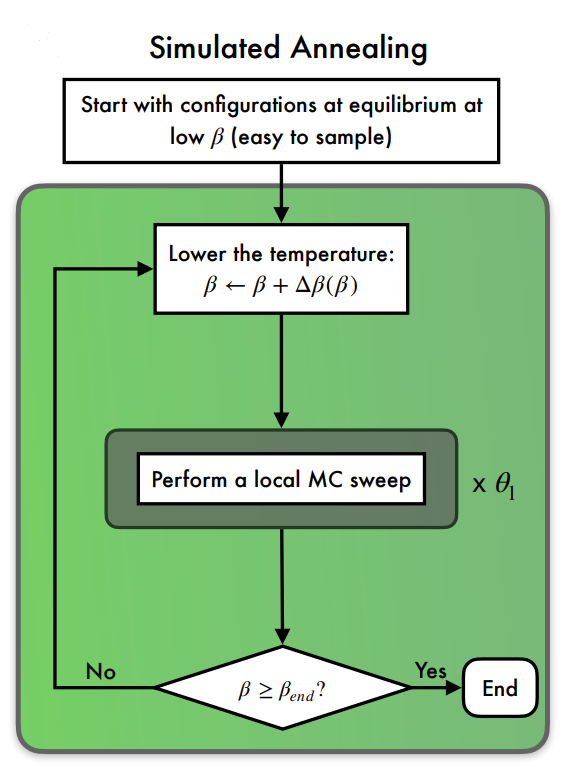

In [66]:
Image(
    "notebook_images/SA.png"
)

15 -1.68892 -1.65394 15.519


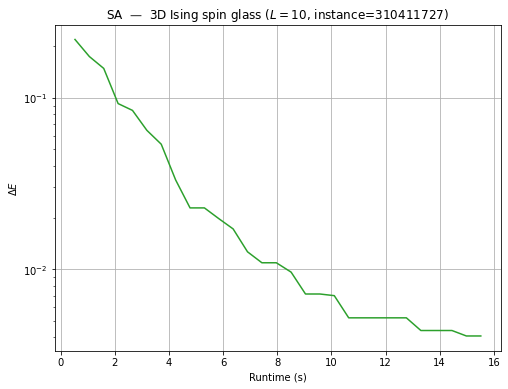

In [25]:
# Population size (number of replicas)
pop_size = 100_000

# number of temperature steps
num_temps = 30

# Disorder instance
instance = 310411727  # hard instance
E_gs = -1.69300   # ground state energy for the hard instance
# instance = 10069     # easy instance (uncomment to switch)
#E_gs = -1.74178   # ground state energy for the easy instance

# Load coupling matrix
J = read_couplings(f'./Data/Alpha/Couplings/couplings_L{L}_R1_seed{instance}.txt', N).to(device)


temperatures, observ, elapsed_time = simulated_annealing(
    L, J, pop_size, local_moves, Tstart, Tend, Observables,
    num_temps_determiner=num_temps, schedule=schedule
)


time_list = np.array(observ.get_elapsed_times())
min_energy_list = np.array(observ.get_running_min_energy()[1:])
print(local_moves, f"{np.min(min_energy_list):.5f}", f'{observ.get_observable_history("mean_energy")[-1]:.5f}', f"{elapsed_time:.3f}")


plt.figure(figsize=(8, 6))
plt.title(f"SA  —  3D Ising spin glass ($L={L}$, instance={instance})")
plt.plot(time_list, min_energy_list - E_gs, color="#2ca02c")
plt.xlabel("Runtime (s)")
plt.ylabel(r"$\Delta E$")
plt.yscale("log")
plt.grid()
plt.show()

# Population Annealing

PA adds a Boltzmann reweighting + resampling step before the MC sweeps at each temperature, concentrating the population near lower-energy states.

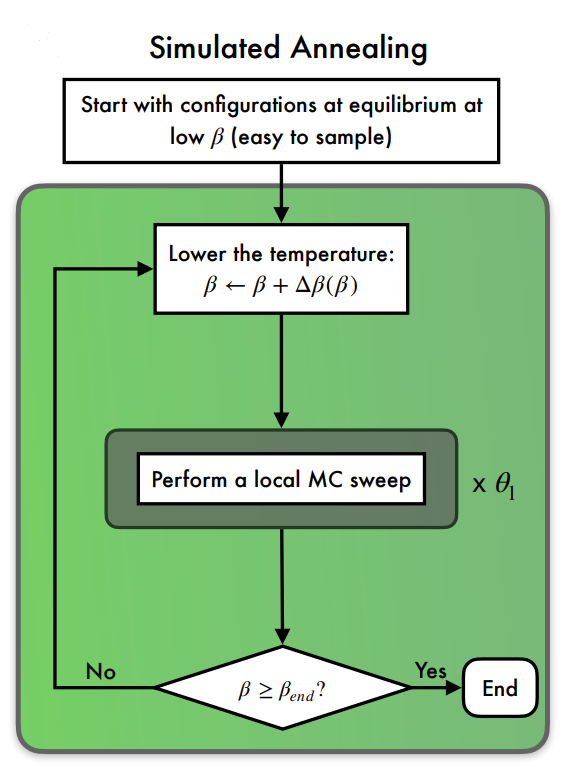

In [67]:
Image(
    "notebook_images/PA.png"
)

15 -1.69300 -1.69275 16.263


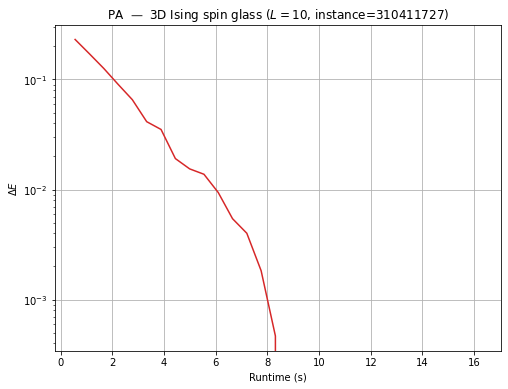

In [26]:
# Population size (number of replicas)
pop_size = 100_000

# number of temperature steps
num_temps = 30  

# Disorder instance
instance = 310411727  # hard instance
E_gs = -1.69300   # ground state energy for the hard instance
# instance = 10069     # easy instance (uncomment to switch)
#E_gs = -1.74178   # ground state energy for the easy instance

# Load coupling matrix
J = read_couplings(f'./Data/Alpha/Couplings/couplings_L{L}_R1_seed{instance}.txt', N).to(device)

temperatures, observ, elapsed_time = population_annealing(
    L, J, pop_size, local_moves, Tstart, Tend, Observables,
    num_temps_determiner=num_temps, schedule=schedule
)


time_list = np.array(observ.get_elapsed_times())
min_energy_list = np.array(observ.get_running_min_energy()[1:])
print(local_moves, f"{np.min(min_energy_list):.5f}", f'{observ.get_observable_history("mean_energy")[-1]:.5f}', f"{elapsed_time:.3f}")


plt.figure(figsize=(8, 6))
plt.title(f"PA  —  3D Ising spin glass ($L={L}$, instance={instance})")
plt.plot(time_list, min_energy_list - E_gs, color="#d62728")
plt.xlabel("Runtime (s)")
plt.ylabel(r"$\Delta E$")
plt.yscale("log")
plt.grid()
plt.show()

# Global Annealing

GA trains a lightweight MADE network on the current population at the start and retrains it at each temperature step. Between local MC sweeps, it proposes full-configuration global moves via the learned model, accepted/rejected by a Metropolis criterion that corrects for the proposal bias.

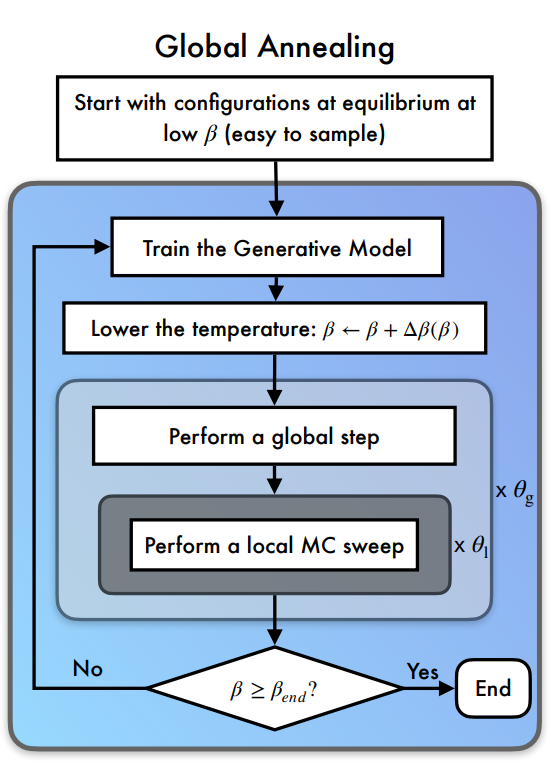

In [68]:
Image(
    "notebook_images/GA.png"
)

5 15 -1.69300 -1.69267 14.257 165.672


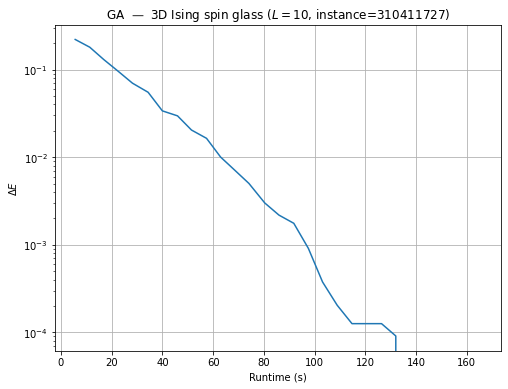

In [28]:
# Population size (number of replicas)
pop_size = 100_000

# number of temperature steps
num_temps = 30  

# Disorder instance
instance = 310411727  # hard instance
E_gs = -1.69300   # ground state energy for the hard instance
# instance = 10069     # easy instance (uncomment to switch)
#E_gs = -1.74178   # ground state energy for the easy instance

# Load coupling matrix
J = read_couplings(f'./Data/Alpha/Couplings/couplings_L{L}_R1_seed{instance}.txt', N).to(device)



temperatures, observ, elapsed_train_time, elapsed_annealing_time = global_annealing(
    L, J, pop_size, global_moves, local_moves, Tstart, Tend, Observables,
    schedule=schedule,
    num_epochs_start=num_epochs_start,
    num_epochs_retrain=num_epochs_retrain,
    batch_size=batch_size,
    num_temps_determiner=num_temps
)


time_list = np.array(observ.get_elapsed_times())
min_energy_list = np.array(observ.get_running_min_energy()[1:])
print(global_moves, local_moves, f"{np.min(min_energy_list):.5f}", f'{observ.get_observable_history("mean_energy")[-1]:.5f}', f"{elapsed_train_time:.3f}", f"{elapsed_annealing_time:.3f}")


plt.figure(figsize=(8, 6))
plt.title(f"GA  —  3D Ising spin glass ($L={L}$, instance={instance})")
plt.plot(time_list, min_energy_list - E_gs, color="#1f77b4")
plt.xlabel("Runtime (s)")
plt.ylabel(r"$\Delta E$")
plt.yscale("log")
plt.grid()
plt.show()

# Algorithm Comparison

We sweep over three time budgets by varying `num_temps` (the number of temperature steps). More steps → longer runtime. The `logT` schedule spaces temperatures logarithmically between `Tstart` and `Tend`.

Each algorithm is run for each setting and we collect the per-step timestamps and running minimum energy.

In [29]:
# Keep the population size fixed
pop_size = 100_000

# Disorder instance
instance = 310411727  # hard instance
E_gs = -1.69300   # ground state energy for the hard instance
# instance = 10069     # easy instance (uncomment to switch)
#E_gs = -1.74178   # ground state energy for the easy instance


# Load coupling matrix
J = read_couplings(f'./Data/Alpha/Couplings/couplings_L{L}_R1_seed{instance}.txt', N).to(device)

# Running times (in seconds) for the temperature schedules that we want to compare
max_time_list = np.array([30, 60, 180])

# Storage: results[algo_name] = list of (elapsed_times, running_min) per num_temps
results = {"SA": [], "PA": [], "GA": []}

In [36]:
# Simulated annealing (SA)


# factor of conversion between time and temperature depends on hardware
num_temps = 15
temperatures, observ, elapsed_time = simulated_annealing(
    L, J, pop_size, local_moves, Tstart, Tend, Observables,
    num_temps_determiner=num_temps, schedule=schedule
)
time_per_temp = num_temps/elapsed_time  # seconds per temperature step (approximate)
num_temps_list = (max_time_list*time_per_temp +2).astype(int)


for nt in num_temps_list:
    temperatures, observ, elapsed_time = simulated_annealing(
        L, J, pop_size, local_moves, Tstart, Tend, Observables,
        num_temps_determiner=nt, schedule=schedule
    )
    rt = observ.get_elapsed_times()
    rm = observ.get_running_min_energy()
    # keep only the entries recorded after start_time (skip the pre-thermalization entry)
    results["SA"].append((rt, rm[1:]))
    print(f"SA  num_temps={nt:>4d}  |  min_E/N = {rm[-1]:.5f}  |  time = {elapsed_time:.1f} s")


SA  num_temps=  61  |  min_E/N = -1.69202  |  time = 32.4 s
SA  num_temps= 121  |  min_E/N = -1.69287  |  time = 65.0 s
SA  num_temps= 361  |  min_E/N = -1.69287  |  time = 196.6 s


In [37]:
# Population annealing (PA)

# factor of conversion between time and temperature depends on hardware
num_temps = 15
temperatures, observ, elapsed_time = population_annealing(
    L, J, pop_size, local_moves, Tstart, Tend, Observables,
    num_temps_determiner=num_temps, schedule=schedule
)
time_per_temp = num_temps/elapsed_time  # seconds per temperature step (approximate)
num_temps_list = (max_time_list*time_per_temp +2).astype(int)


for nt in num_temps_list:
    temperatures, observ, elapsed_time = population_annealing(
        L, J, pop_size, local_moves, Tstart, Tend, Observables,
        num_temps_determiner=nt, schedule=schedule
    )
    rt = observ.get_elapsed_times()
    rm = observ.get_running_min_energy()
    results["PA"].append((rt, rm[1:]))
    print(f"PA  num_temps={nt:>4d}  |  min_E/N = {rm[-1]:.5f}  |  time = {elapsed_time:.1f} s")

PA  num_temps=  59  |  min_E/N = -1.69300  |  time = 32.7 s
PA  num_temps= 116  |  min_E/N = -1.69287  |  time = 65.0 s
PA  num_temps= 344  |  min_E/N = -1.69300  |  time = 192.8 s


In [44]:
# Global annealing (GA)


# factor of conversion between time and temperature depends on hardware
num_temps = 10
temperatures, observ, elapsed_train_time, elapsed_annealing_time = global_annealing(
    L, J, pop_size, global_moves, local_moves, Tstart, Tend, Observables,
    schedule=schedule,
    num_epochs_start=num_epochs_start,
    num_epochs_retrain=num_epochs_retrain,
    batch_size=batch_size,
    num_temps_determiner=num_temps
)
time_per_temp = num_temps/elapsed_annealing_time  # seconds per temperature step (approximate)
num_temps_list = (max_time_list*time_per_temp +2).astype(int)

for nt in num_temps_list:
    temperatures, observ, elapsed_train_time, elapsed_annealing_time = global_annealing(
        L, J, pop_size, global_moves, local_moves, Tstart, Tend, Observables,
        schedule=schedule,
        num_epochs_start=num_epochs_start,
        num_epochs_retrain=num_epochs_retrain,
        batch_size=batch_size,
        num_temps_determiner=nt
    )
    rt = observ.get_elapsed_times()
    rm = observ.get_running_min_energy()
    results["GA"].append((rt, rm[1:]))
    print(f"GA  num_temps={nt:>4d}  |  min_E/N = {rm[-1]:.5f}  |  train time = {elapsed_train_time:.3f} s  |  annealing time = {elapsed_annealing_time:.3f} s ")

GA  num_temps=   7  |  min_E/N = -1.69092  |  train time = 14.104 s  |  annealing time = 33.542 s 
GA  num_temps=  13  |  min_E/N = -1.69287  |  train time = 14.004 s  |  annealing time = 67.889 s 
GA  num_temps=  37  |  min_E/N = -1.69300  |  train time = 14.503 s  |  annealing time = 204.674 s 


## Performance Comparison Plot

We reproduce the figure from the paper: three panels (one per time budget), each showing $\Delta E$ = running minimum energy per spin vs. wall-clock runtime for SA (green), PA (red), and GA (blue).

The y-axis uses a log scale to highlight the orders-of-magnitude differences in convergence speed.

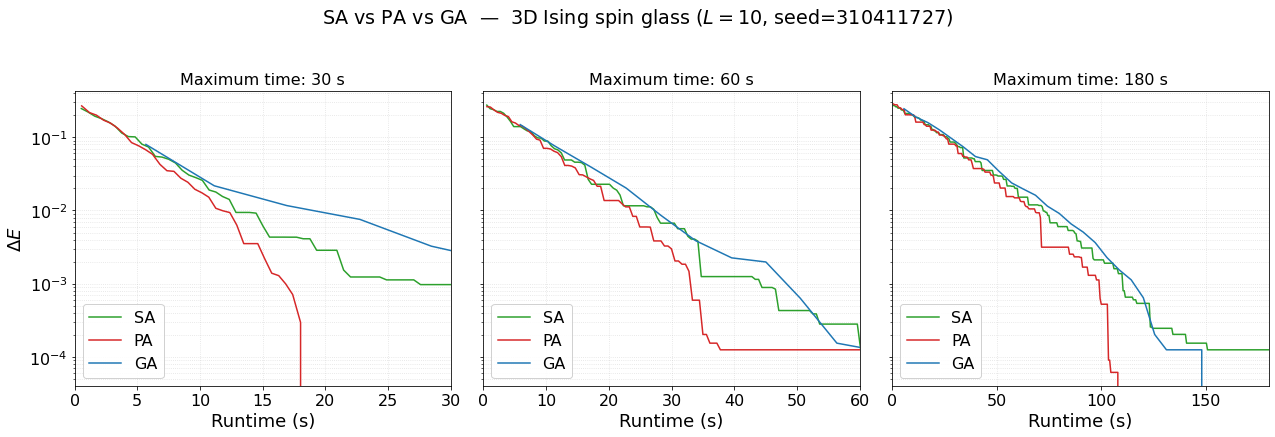

Figure saved to performance_comparison.png


In [62]:
plt.rcParams.update({'font.size': 16}) 
# To set the font size for axis labels
plt.rcParams['axes.labelsize'] = 18 
# To set the font size for tick labels (the numbers on the axes)
plt.rcParams['xtick.labelsize'] = 16 
plt.rcParams['ytick.labelsize'] = 16 
# You can also set the title size
plt.rcParams['axes.titlesize'] = 16 
# And the legend font size
plt.rcParams['legend.fontsize'] = 16



# --- Plotting ---
colors = {"SA": "#2ca02c", "PA": "#d62728", "GA": "#1f77b4"}  # green, red, blue

fig, axes = plt.subplots(1, len(num_temps_list), figsize=(6 * len(num_temps_list), 6),
                         sharey=True)

for idx, nt in enumerate(num_temps_list):
    ax = axes[idx]

    for algo in ["SA", "PA", "GA"]:
        rt, rm = results[algo][idx]
        # ΔE = running minimum energy per spin − ground-state energy per spin
        delta_e = np.array(rm) - E_gs
        ax.semilogy(rt, delta_e, label=algo, color=colors[algo], linewidth=1.5)

    ax.set_title(f"Maximum time: {max_time_list[idx]:.0f} s")
    ax.set_xlim(0, max_time_list[idx])
    #ax.set_ylim(ymin=1e-5)
    ax.set_xlabel("Runtime (s)")
    if idx == 0:
        ax.set_ylabel(r"$\Delta E$")
    ax.legend(loc="lower left", framealpha=0.9)
    ax.grid(True, which="both", ls=":", alpha=0.4)

fig.suptitle(f"SA vs PA vs GA  —  3D Ising spin glass ($L={L}$, seed={instance})",
              y=1.02)
plt.tight_layout()
plt.savefig("performance_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print("Figure saved to performance_comparison.png")

## Summary Table

Final minimum energies per spin and total runtimes for each algorithm and time budget.

In [63]:
print(f"{'Algo':<6} {'num_temps':>10} {'min E/N':>12} {'ΔE':>12} {'Runtime (s)':>14}")
print("-" * 60)
for algo in ["SA", "PA", "GA"]:
    for idx, nt in enumerate(num_temps_list):
        rt, rm = results[algo][idx]
        print(f"{algo:<6} {nt:>10d} {rm[-1]:>12.5f} {rm[-1] - E_gs:>12.5f} {rt[-1]:>14.1f}")

Algo    num_temps      min E/N           ΔE    Runtime (s)
------------------------------------------------------------
SA              7     -1.69202      0.00098           32.4
SA             13     -1.69287      0.00013           65.0
SA             37     -1.69287      0.00013          196.6
PA              7     -1.69300     -0.00000           32.7
PA             13     -1.69287      0.00013           65.0
PA             37     -1.69300     -0.00000          192.8
GA              7     -1.69092      0.00208           33.5
GA             13     -1.69287      0.00013           67.9
GA             37     -1.69300     -0.00000          204.7
